# Questão 6 - Dimensão de calendário

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import duckdb
from IPython.display import Image, display

### Caminho base do projeto

In [2]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


Carregando os dados em um dataframe Pandas para melhor visulização. 

In [3]:
DATA_PATH = BASE_PATH / "data"

RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"
INTERMEDIATE_PATH = DATA_PATH / "intermediate"
MARTS_PATH = DATA_PATH / "marts"

SQL_PATH = BASE_PATH / "sql"
IMAGES_PATH = BASE_PATH / "imagens"

Questão 6.1 - Código SQL
Código com:

• Desenvolvimento de u m calendário com os dias d a
semana (em portugues)

• LEFT JOIN entre o calendário e a tabela d e vendas

• agregação de vendas por dia (soma de valor_venda),

• substituição de valores nulos por zero para dias sem
vendas


In [4]:
query_path = SQL_PATH / "6_1_codigo.sql"

with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

print(f"Link para a query: {SQL_PATH / '6_1_codigo.sql'}")


Link para a query: /Users/richardgomes/lh-nautical-data-project/sql/6_1_codigo.sql


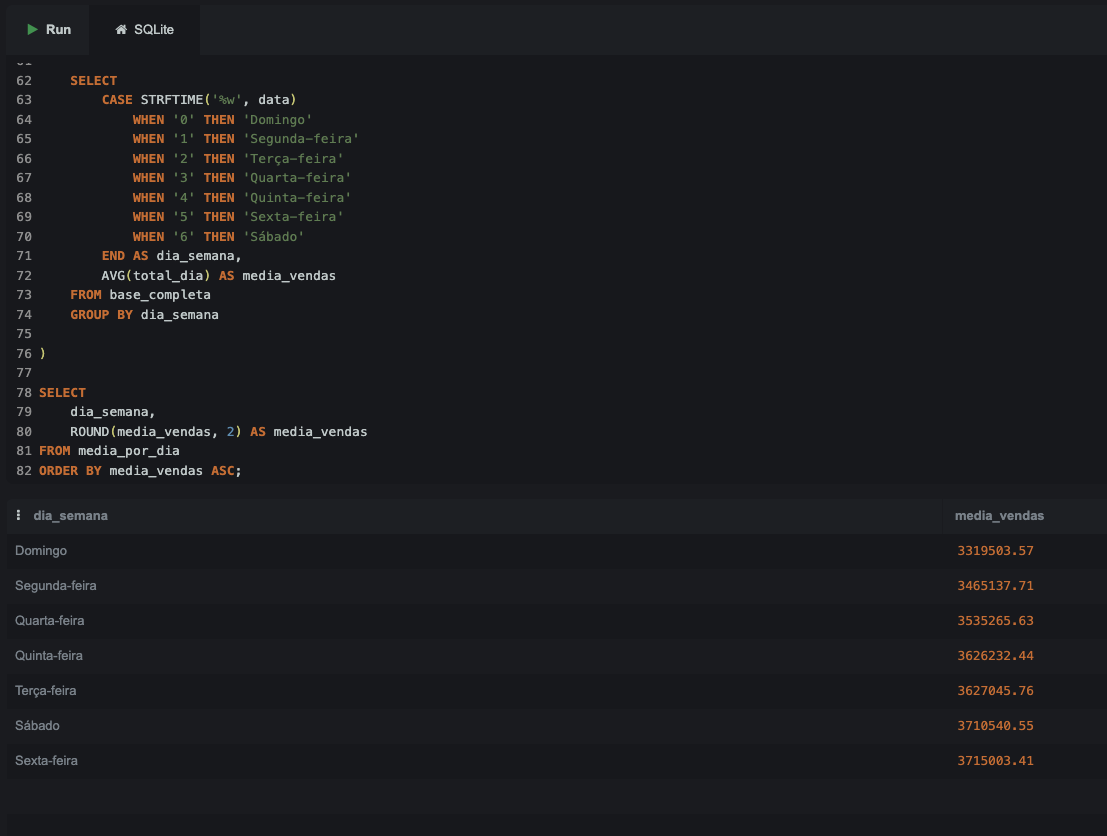

In [5]:
display(Image(filename=IMAGES_PATH / "6_1_codigo.png"))


Prevendo que vou precisar dessas datas em uma dim_date para o dashboard vou gera-la em Python aqui mesmo.

Intervalo de datas (mesmo da sua análise)

In [6]:
date_range = pd.date_range(start="2023-01-01", end="2024-12-31")



Dias da semana já em português

In [7]:

date_range = pd.date_range(start="2023-01-01", end="2024-12-31")

dim_date = pd.DataFrame({
    "data": date_range
})

dim_date["ano"] = dim_date["data"].dt.year
dim_date["mes"] = dim_date["data"].dt.month
dim_date["dia"] = dim_date["data"].dt.day

dim_date["nome_mes"] = dim_date["data"].dt.month_name().map({
    "January": "Janeiro",
    "February": "Fevereiro",
    "March": "Março",
    "April": "Abril",
    "May": "Maio",
    "June": "Junho",
    "July": "Julho",
    "August": "Agosto",
    "September": "Setembro",
    "October": "Outubro",
    "November": "Novembro",
    "December": "Dezembro"
})

dim_date["dia_da_semana_num"] = dim_date["data"].dt.weekday
dim_date["dia_da_semana"] = dim_date["data"].dt.day_name()


traducao = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

dim_date["dia_da_semana"] = dim_date["dia_da_semana"].map(traducao)
dim_date["fim_de_semana"] = dim_date["dia_da_semana_num"].isin([5, 6])
dim_date["data_chave"] = dim_date["data"].dt.strftime("%Y%m%d").astype(int)


In [8]:
dim_date

,data,ano,mes,dia,nome_mes,dia_da_semana_num,dia_da_semana,fim_de_semana,data_chave
0,2023-01-01,2023,1,1,Janeiro,6,Domingo,True,20230101
1,2023-01-02,2023,1,2,Janeiro,0,Segunda-feira,False,20230102
2,2023-01-03,2023,1,3,Janeiro,1,Terça-feira,False,20230103
3,2023-01-04,2023,1,4,Janeiro,2,Quarta-feira,False,20230104
4,2023-01-05,2023,1,5,Janeiro,3,Quinta-feira,False,20230105
...,...,...,...,...,...,...,...,...,...
726,2024-12-27,2024,12,27,Dezembro,4,Sexta-feira,False,20241227
727,2024-12-28,2024,12,28,Dezembro,5,Sábado,True,20241228
728,2024-12-29,2024,12,29,Dezembro,6,Domingo,True,20241229
729,2024-12-30,2024,12,30,Dezembro,0,Segunda-feira,False,20241230


In [9]:
dim_date.to_csv(MARTS_PATH / "dim_date.csv", index=False)